<h1> Predviđanje nivoa zavisnosti od mobilnih telefona kod tinejdžera </h1>

<h2> Uvod </h2>

Zavisnost od mobilnih telefona je sveprisutan problem koji utiče na zdravlje, obrazovanje i socijalizaciju mladih koji su najviše pogođeni ovim problemom.

Cilj ovog projekta je predviđanje nivoa zavisnosti od mobilnih telefona uzimajući u obzir sociološke i zdravstvene faktore, kao i podatke o navikama korišćenja telefona. Ideja je da razvijemo modele koji će na osnovu spomenutih faktora uspješno predviđati nivo zavisnosti, o čemu će biti više riječi u drugom dijelu rada. 
U ovom segmentu ćemo se baviti analizom podataka kako bismo identifikovali atribute koji najviše utiču na pojavu zavisnosti. Naš cilj je da  odgovorimo na pitanje u kojoj mjeri na zavisnost utiču sociološki i psihološki faktori, poput nivoa depresije, samopouzdanja i kvaliteta sna, u poređenju sa činjeničnim faktorima korišćenja, kao što je ukupno vrijeme provedeno na telefonu.


<h3> Podaci </h3>

Skup podataka je sintetički i sastoji se od 3000 unosa i 25 kolona. Neki od atributa su: age, sleep_hours, academic_performance, anxiety_level, phone_checks_per_day, daily_usage_hours, time_spent_on_social_media...

Predikcija će se vršiti nad atributom addiction_level, koji predstavlja nivo zavisnosti u rasponu 1 - 10 (kontinualne vrijednosti).

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("src"))

df = pd.read_csv("data/podaci.csv")
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


<h2> Vizuelizacija podataka</h2>

U nastavku ćemo prikazati vizuelnu reprezentaciju podataka i na osnovu grafikona izvesti zaključke relevantne za dalje istraživanje.

<h3> Sociološki faktori i navike</h3>

U ovom dijelu ćemo se primarno fokusirati na analizu uticaja socioloških faktora i životnih navika na razmatrani problem.

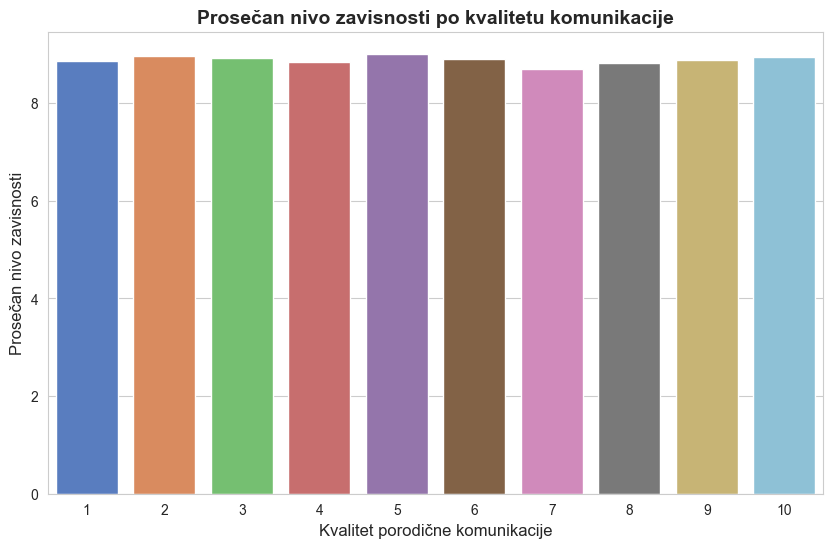

In [30]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(data=df, 
            x='Family_Communication', 
            y='Addiction_Level', 
            palette='muted', 
            hue='Family_Communication', 
            legend=False, 
            errorbar=None)

plt.title('Prosečan nivo zavisnosti po kvalitetu komunikacije', fontsize=14, fontweight='bold')
plt.xlabel('Kvalitet porodične komunikacije', fontsize=12)
plt.ylabel('Prosečan nivo zavisnosti', fontsize=12)

plt.show()

Na osnovu prikazanog grafikona možemo zaključiti da kvalitetna komunikacija sa članovima porodice ne znači nužno i niži nivo zavisnosti, visoko su zavisni i oni sa boljom i oni sa lošijom porodičnom komunikacijom, što nam govori da nam ovaj atribut neće biti od velikog značaja. 

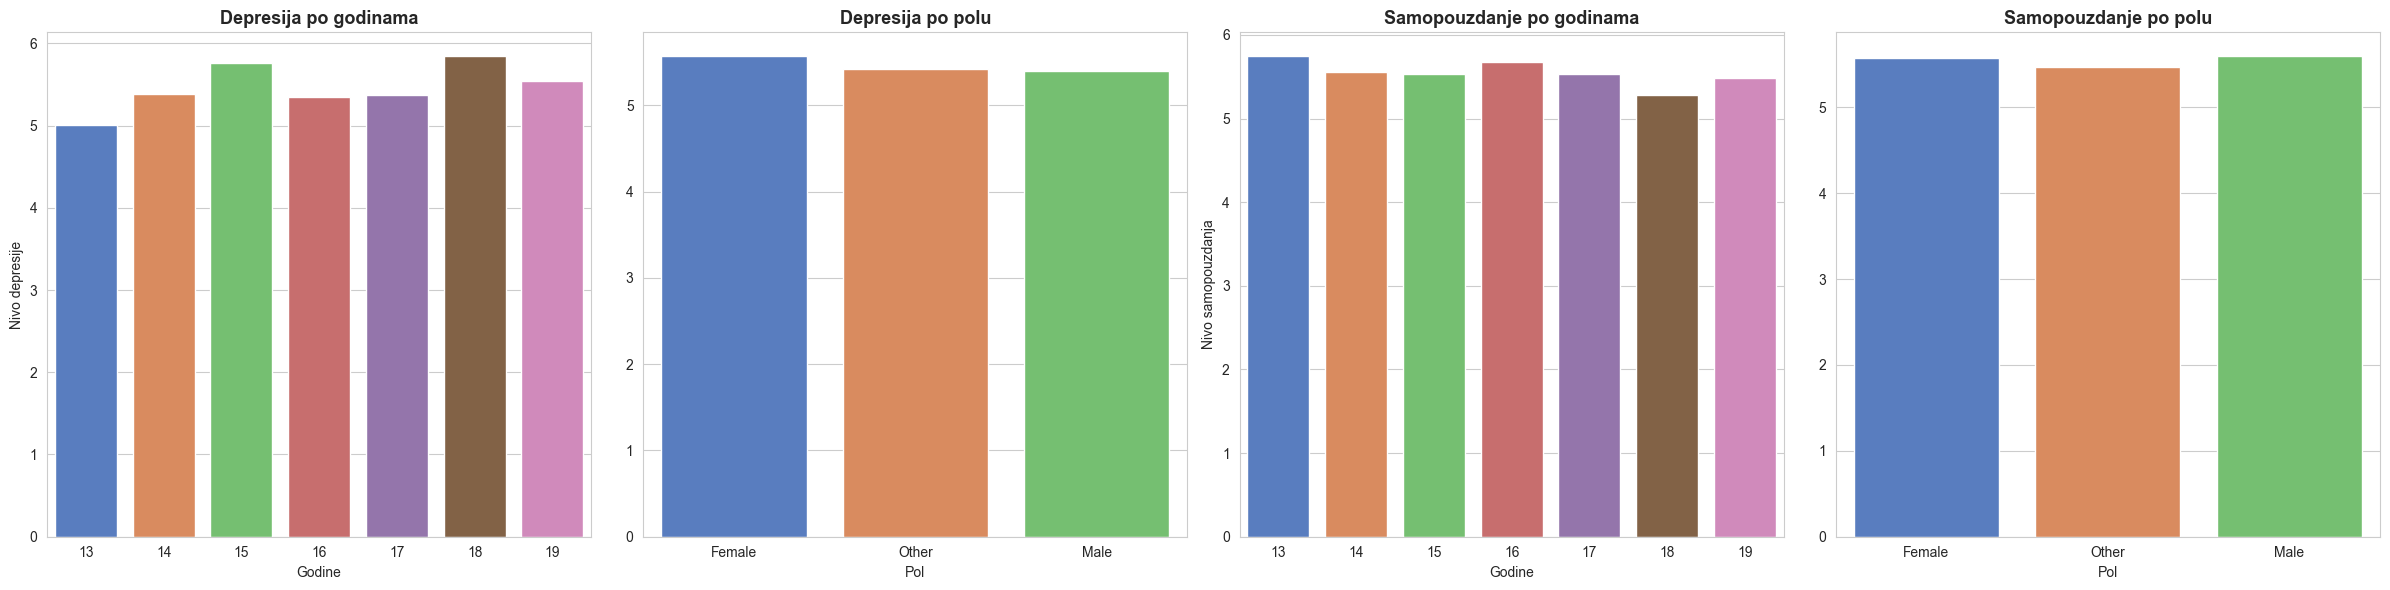

In [36]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

sns.barplot(data=df, x='Age', y='Depression_Level', ax=axes[0], palette='muted', hue='Age', legend=False, errorbar=None)
axes[0].set_title('Depresija po godinama', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Godine')
axes[0].set_ylabel('Nivo depresije')

sns.barplot(data=df, x='Gender', y='Depression_Level', ax=axes[1], palette='muted', hue='Gender', legend=False, errorbar=None)
axes[1].set_title('Depresija po polu', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pol')
axes[1].set_ylabel('')

sns.barplot(data=df, x='Age', y='Self_Esteem', ax=axes[2], palette='muted', hue='Age', legend=False, errorbar=None)
axes[2].set_title('Samopouzdanje po godinama', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Godine')
axes[2].set_ylabel('Nivo samopouzdanja')

sns.barplot(data=df, x='Gender', y='Self_Esteem', ax=axes[3], palette='muted', hue='Gender', legend=False, errorbar=None)
axes[3].set_title('Samopouzdanje po polu', fontsize=13, fontweight='bold')
axes[3].set_xlabel('Pol')
axes[3].set_ylabel('')

plt.tight_layout()
plt.show()

Možemo primijetiti da ispitanici starosti 15 i 18 godina imaju neznatno izraženiji nivo depresije, dok oni starosti 13 godina imaju niži nivo, što se slaže sa tim da je nivo samopouzdanja povišen u tom uzrastu od 13 godina. Takođe, vidimo da su nivoi samopouzdanja jednako distribuirani po polovima, dok su djevojčice u prosjeku malo depresivnije u odnosu na ostale polove.

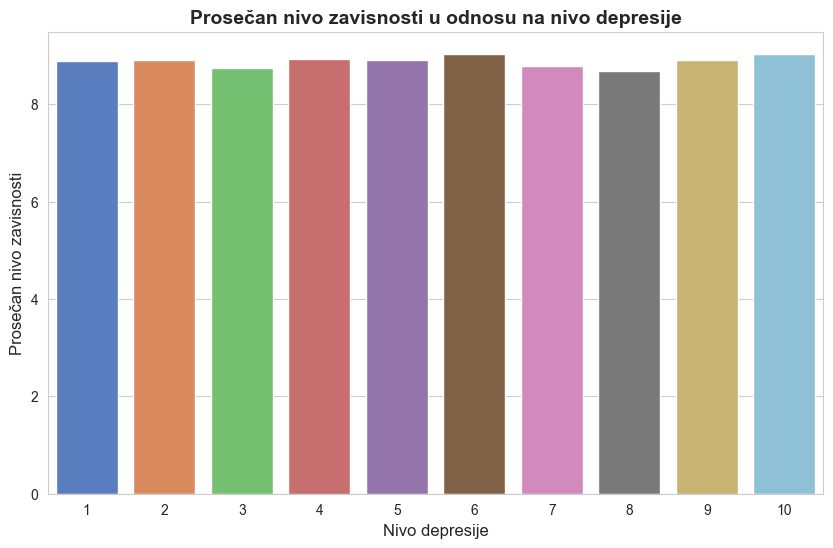

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(data=df, 
            x='Depression_Level', 
            y='Addiction_Level', 
            palette='muted', 
            hue='Depression_Level', 
            legend=False, 
            errorbar=None)

plt.title('Prosečan nivo zavisnosti u odnosu na nivo depresije', fontsize=14, fontweight='bold')
plt.xlabel('Nivo depresije', fontsize=12)
plt.ylabel('Prosečan nivo zavisnosti', fontsize=12)

plt.show()

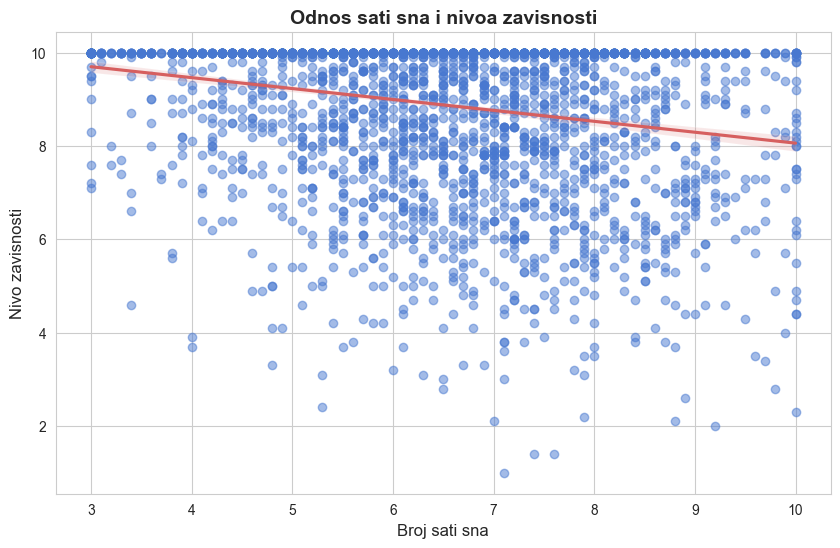

In [39]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='Sleep_Hours', y='Addiction_Level', 
            scatter_kws={'alpha':0.5, 'color':'#4878d0'}, 
            line_kws={'color':'#d65f5f'})

plt.title('Odnos sati sna i nivoa zavisnosti', fontsize=14, fontweight='bold')
plt.xlabel('Broj sati sna', fontsize=12)
plt.ylabel('Nivo zavisnosti', fontsize=12)

plt.show()

Prikazani rezultati potvrđuju da je narušen san direktna posljedica visokog nivoa zavisnosti. Primjećena tendencija opadanja sati sna kod najugroženijih grupa ukazuje da je ovaj faktor jedan od pouzdanijih pokazatelja problema zavisnosti.

<h3> Demografiski faktori </h3>

U ovom dijelu istražujemo kako se nivo zavisnosti mijenja u odnosu na pol i godine ispitanika. 

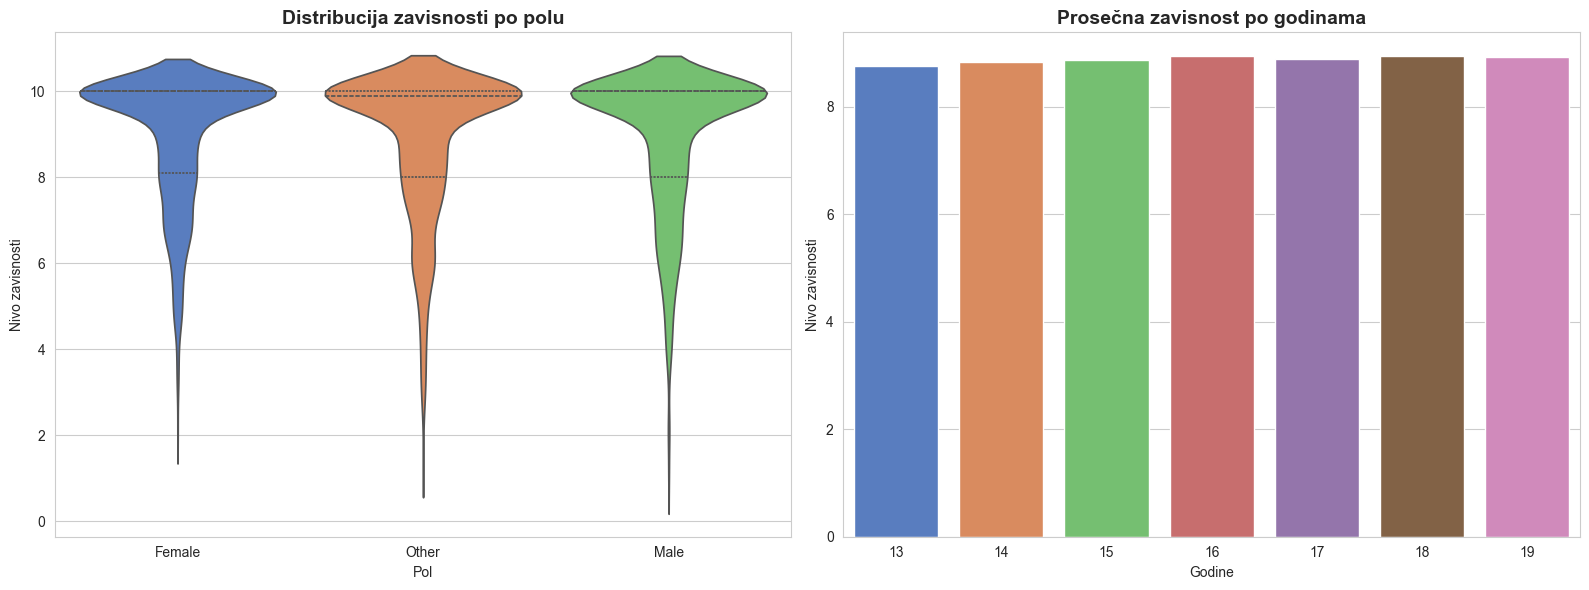

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df, x='Gender', y='Addiction_Level', ax=axes[0], palette='muted', hue='Gender', legend=False, inner="quartile")
axes[0].set_title('Distribucija zavisnosti po polu', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pol')
axes[0].set_ylabel('Nivo zavisnosti')

sns.barplot(data=df, x='Age', y='Addiction_Level', ax=axes[1], palette='muted', hue='Age', legend=False, errorbar=None)
axes[1].set_title('Prosečna zavisnost po godinama', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Godine')
axes[1].set_ylabel('Nivo zavisnosti')

plt.tight_layout()
plt.show()

Na osnovu ovih grafikona zaključujemo da ni pol ni godine neće biti značajni prediktori u našoj analizi. Približno jednaka zavisnost je za sve polove i uzraste, takođe vidljiv je problem jako malog broja ispitanika sa niskim nivoom zavisnosti, koji će se kasnije dodatno razmatrati.

<h3> Usage pattern </h3>

U nastavku fokus  će biti na faktorima koji se tiču podataka vezanih za način upotrebe telefona. Ovdje očekujemo bolje prediktore u odnosu na prethodno analizirane demografske i sociološke faktore.

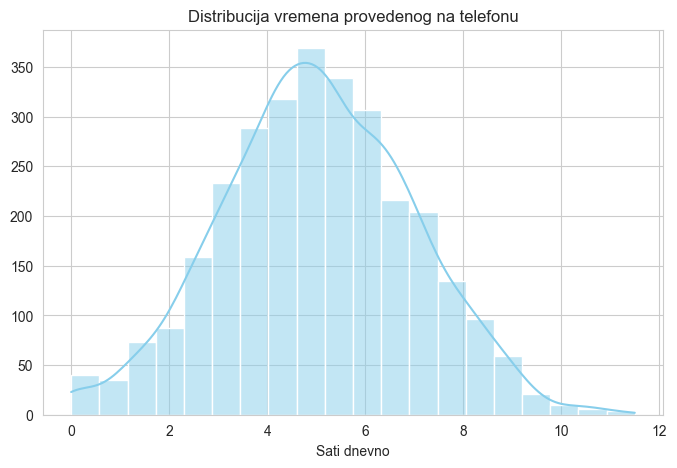

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['Daily_Usage_Hours'], kde=True, bins=20, color='skyblue')
plt.title('Distribucija vremena provedenog na telefonu')
plt.xlabel('Sati dnevno')
plt.ylabel('')
plt.grid(True)
plt.show()

Uočavamo da najveći broj tinejdžera provodi između 4-6 sati dnevno na telefonima, što je "standard" za današnju generaciju. Veoma mali broj tinejdžera koristi telefon manje od 2 sata, oni su manjina u ovom datasetu, a postoji i druga krajnost - korišćenje više od 10 sati.

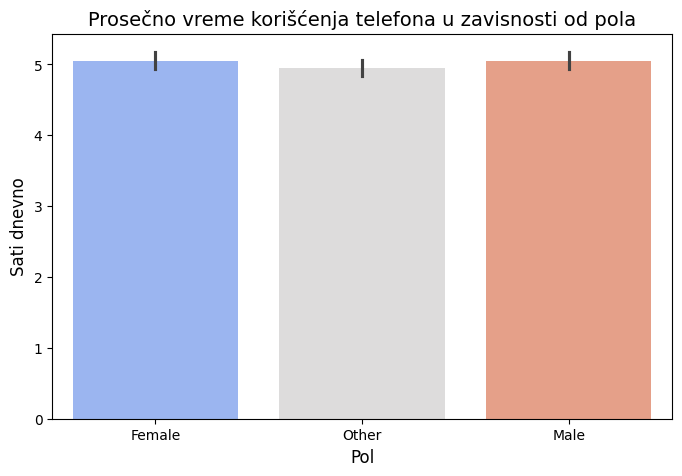

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Gender', y='Daily_Usage_Hours', palette='coolwarm', hue='Gender', legend=False)
plt.title('Prosečno vreme korišćenja telefona u zavisnosti od pola', fontsize=14)
plt.ylabel('Sati dnevno', fontsize=12)
plt.xlabel('Pol', fontsize=12)
plt.show()

Približno jednako vrijeme provedeno na telefonu za sve polove.

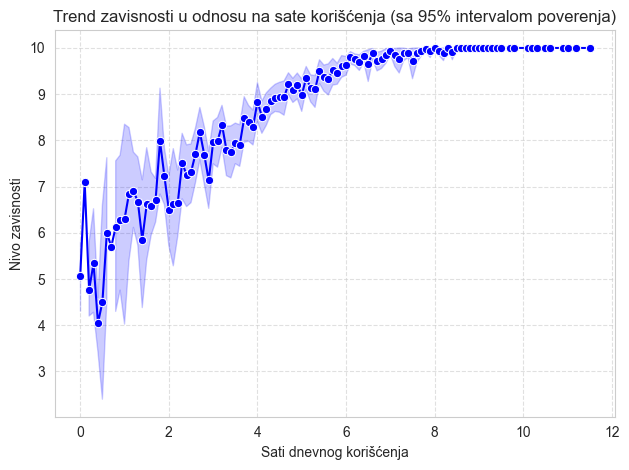

In [53]:
sns.lineplot(data=df, x='Daily_Usage_Hours', y='Addiction_Level', marker='o', color='blue', errorbar=('ci', 95))

plt.title('Trend zavisnosti u odnosu na sate korišćenja (sa 95% intervalom poverenja)')
plt.xlabel('Sati dnevnog korišćenja')
plt.ylabel('Nivo zavisnosti')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

 Za razliku od pola ili komunikacije u porodici, ovdje vidimo da vrijeme direktno diktira nivo zavisnosti. Najzapaženiji skok zavisnosti se dešava u intervalu od 2 do 6 sati svakodnevnog korišćenja. Nakon 8 sati korišćenja, interval povjerenja nestaje, među ispitanicima više nema izuzetaka  i ekstremno dugo korišćenje telefona garantuje maksimalnu zavisnost. 
 
Na samom početku, plava sjenka je najšira, a linija znatno varira. To nam govori da kod tinejdžera koji malo koriste telefon (ispod 2 sata) nivo zavisnosti nije stabilan, tu imamo i one koji su potpuno zdravi, ali i one koji su već u ranoj fazi zavisnosti.  


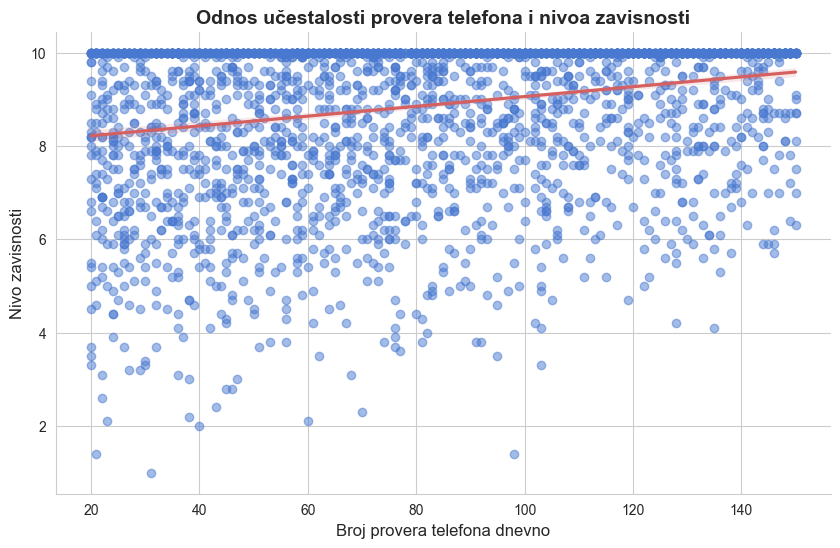

In [51]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='Phone_Checks_Per_Day', y='Addiction_Level', 
            scatter_kws={'alpha':0.5, 'color':'#4878d0'}, 
            line_kws={'color':'#d65f5f'})

plt.title('Odnos učestalosti provera telefona i nivoa zavisnosti', fontsize=14, fontweight='bold')
plt.xlabel('Broj provera telefona dnevno', fontsize=12)
plt.ylabel('Nivo zavisnosti', fontsize=12)

sns.despine()

plt.show()

Postoji direktna povezanost između nivoa zavisnosti i broja provjera telefona. Možemo primijetiti da su veoma rijetki ispitanici sa velikim brojem provjera, a malim nivoom zavisnosti. Čak i oni koji provjeravaju telefon samo 20 puta dnevno imaju prosjek zavisnosti iznad 8.

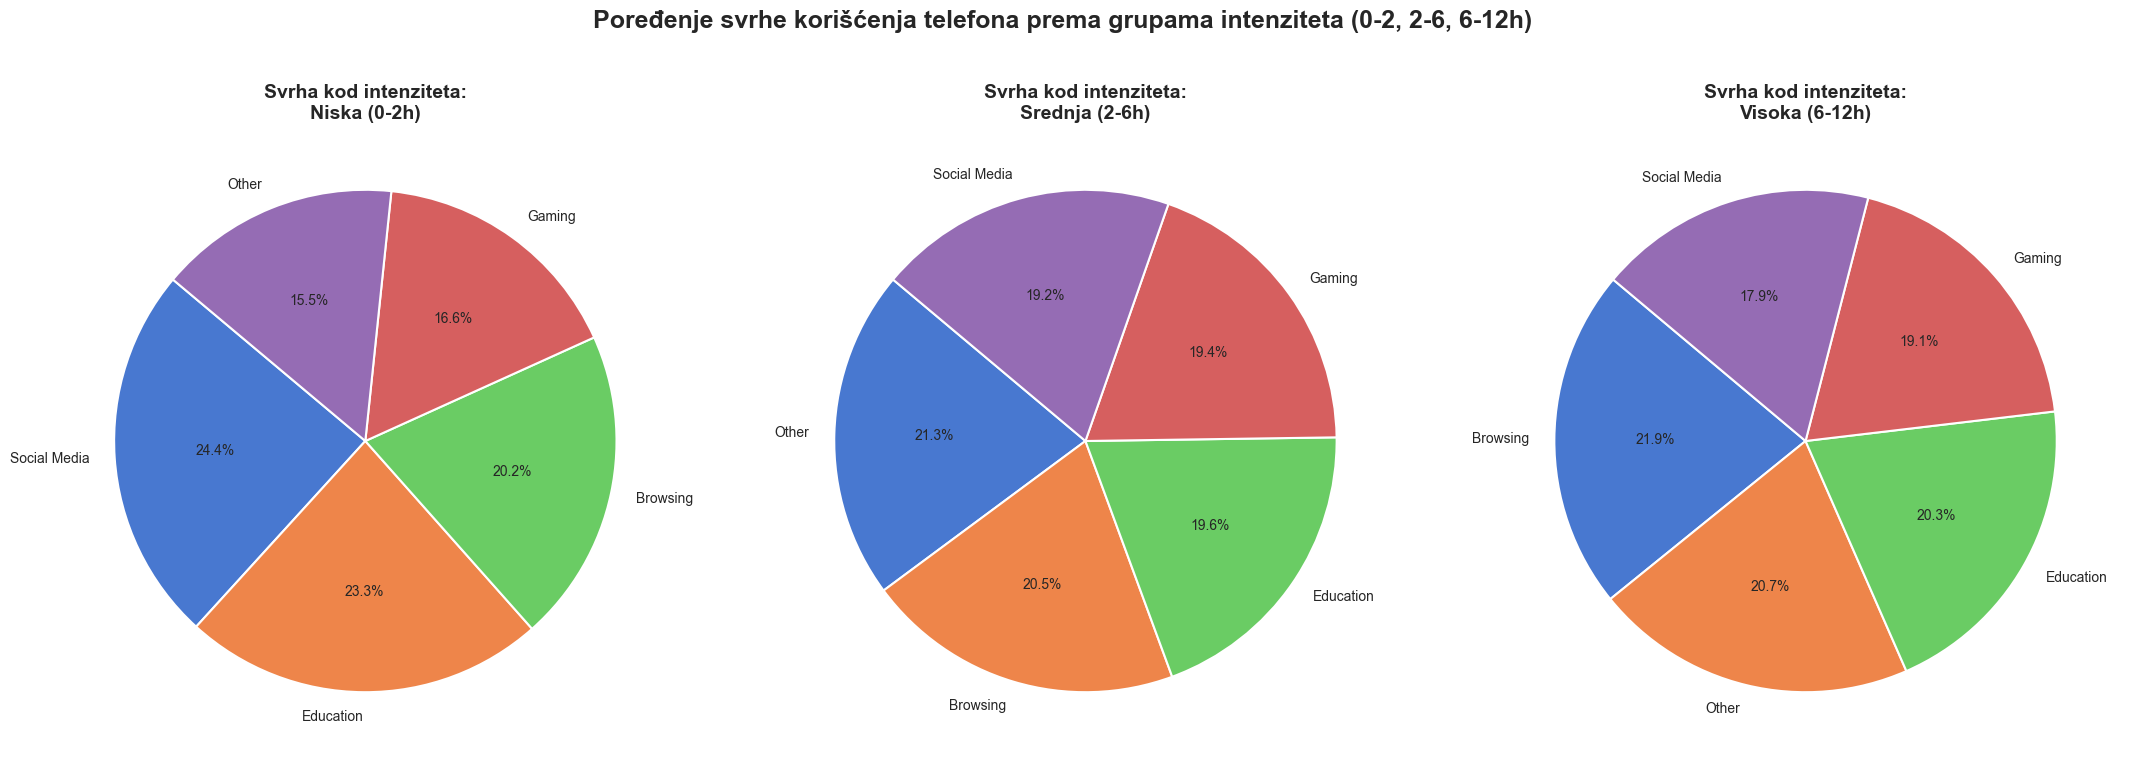

In [54]:
bins = [0, 2, 6, 12]
labels = ['Niska (0-2h)', 'Srednja (2-6h)', 'Visoka (6-12h)']

df['Usage_Intensity'] = pd.cut(df['Daily_Usage_Hours'], bins=bins, labels=labels, include_lowest=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
colors = sns.color_palette('muted')

for i, label in enumerate(labels):
    filtered_df = df[df['Usage_Intensity'] == label]
    counts = filtered_df['Phone_Usage_Purpose'].value_counts()
    
    if not counts.empty:
        axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                    colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    
    axes[i].set_title(f'Svrha kod intenziteta:\n{label}', fontsize=14, fontweight='bold')

plt.suptitle('Poređenje svrhe korišćenja telefona prema grupama intenziteta (0-2, 2-6, 6-12h)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()

df.drop(columns=['Usage_Intensity'], inplace=True)

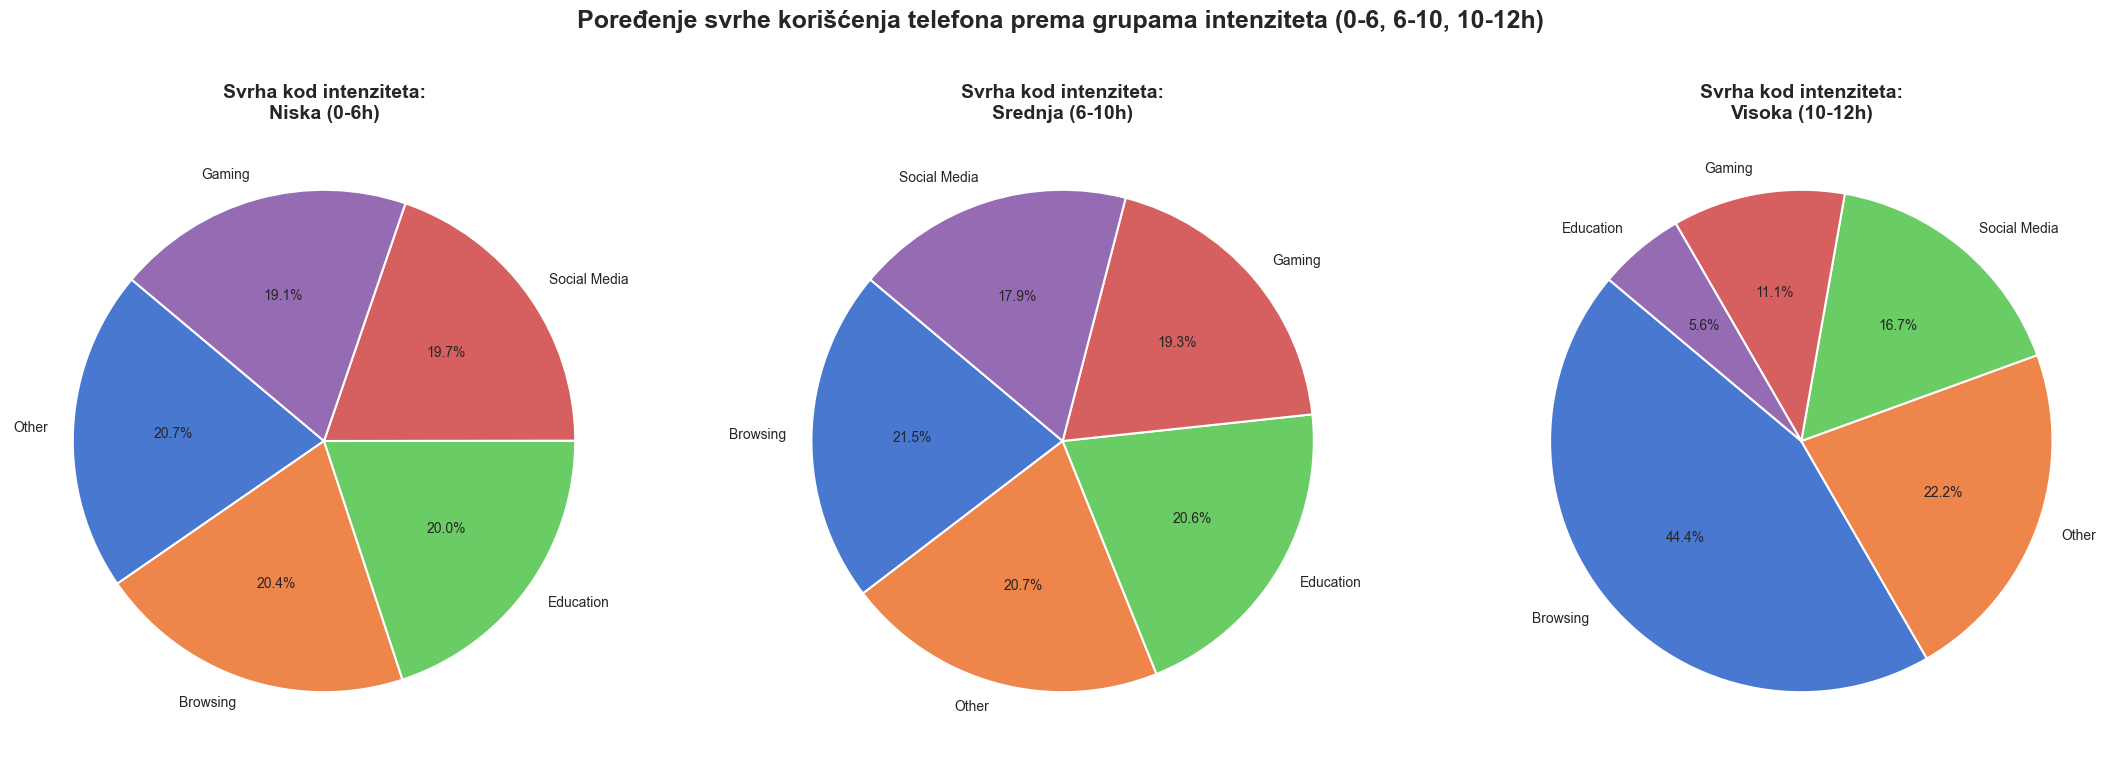

In [56]:
bins = [0, 6, 10,12]
labels = ['Niska (0-6h)', 'Srednja (6-10h)', 'Visoka (10-12h)']

df['Usage_Intensity'] = pd.cut(df['Daily_Usage_Hours'], bins=bins, labels=labels, include_lowest=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
colors = sns.color_palette('muted')

for i, label in enumerate(labels):
    filtered_df = df[df['Usage_Intensity'] == label]
    counts = filtered_df['Phone_Usage_Purpose'].value_counts()
    
    if not counts.empty:
        axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                    colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    
    axes[i].set_title(f'Svrha kod intenziteta:\n{label}', fontsize=14, fontweight='bold')

plt.suptitle('Poređenje svrhe korišćenja telefona prema grupama intenziteta (0-6, 6-10, 10-12h)', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()

df.drop(columns=['Usage_Intensity'], inplace=True)

Na osnovu prikazanih grafikona možemo izvući sljedeće zaključke:

Tinejdžeri koji provode do 10 sati na telefonu i dalje uspevaju da održe balans. Edukacija, zabava i društvene mreže su podjednako zastupljeni. Ovo govori da čak i do 10 sati na telefonu može biti korisna upotreba ako je raspodjela vremena ispravna. 

U grupi od 10-12h, balans potpuno nestaje, browsing (besciljno surfovanje) skače na 44.4%. To je jasan pokazatelj kompulsivnog ponašanja gdje tinejdžer više ne ulazi na telefon sa ciljem, već se "zaglavljuje" u beskonačnom listanju sadržaja tzv. doomscrolling. Takođe, edukacija pada na 5.6%. Ovo je jasan pokazatelj da ekstremna zavisnost negativno utiče na produktivne aktivnosti. Čak i igranje igrica za koje je potrebna vještina i zainteresovanost opada sa 19 na 11 procenata.

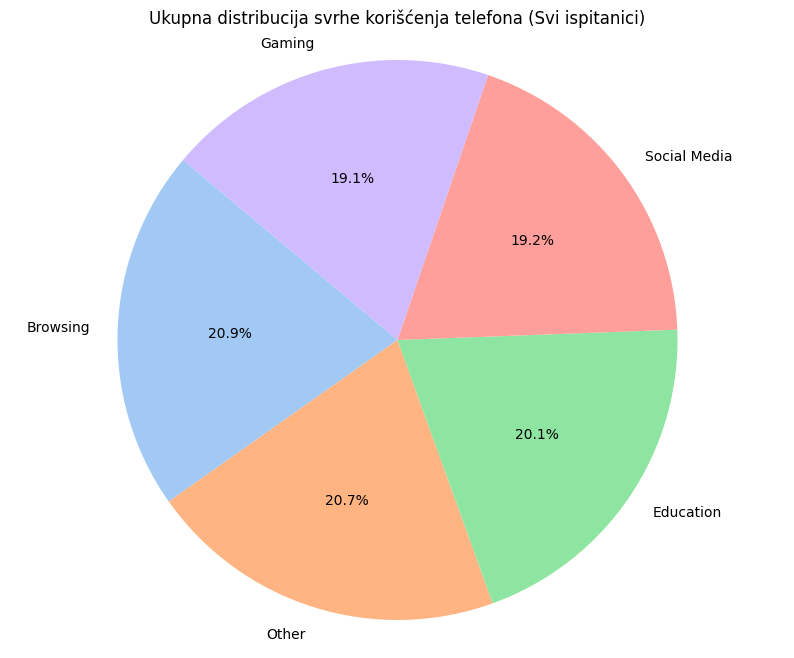

In [ ]:
overall_counts = df['Phone_Usage_Purpose'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(overall_counts,
        labels=overall_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Ukupna distribucija svrhe korišćenja telefona')
plt.axis('equal')

plt.show()

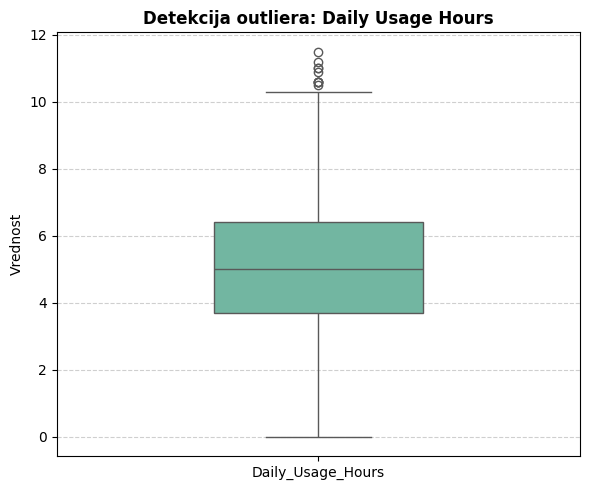

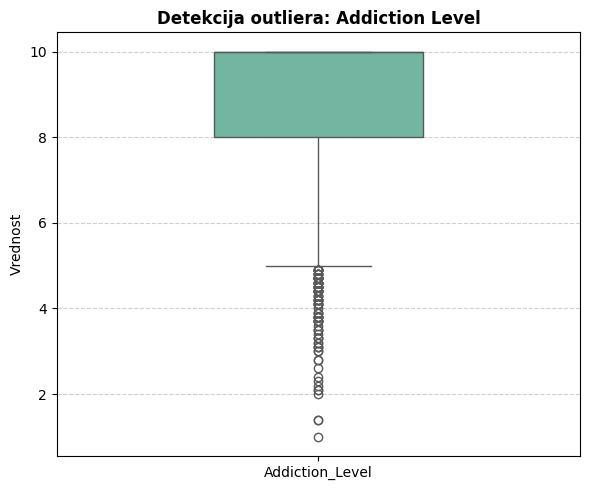

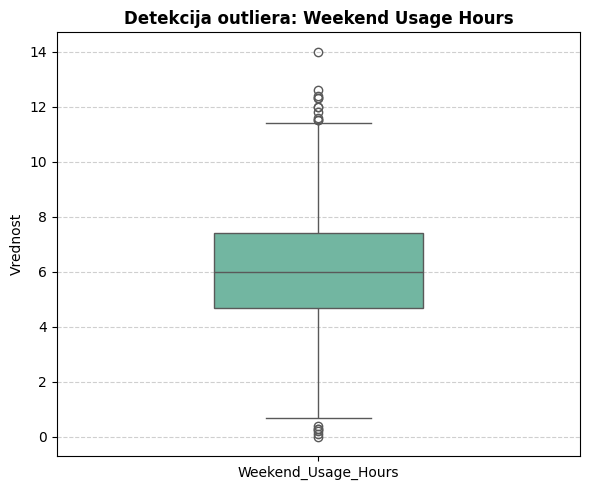

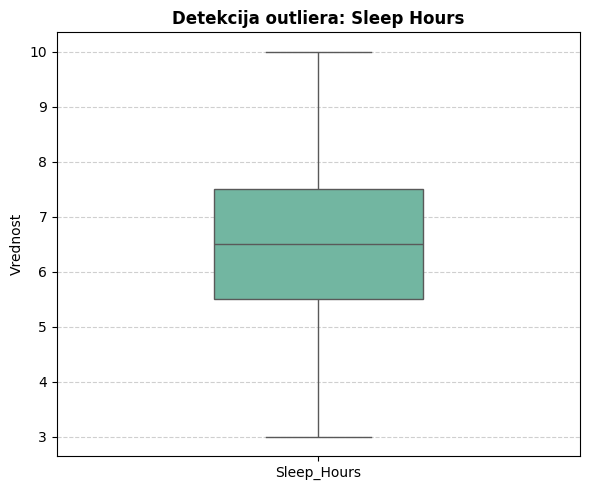

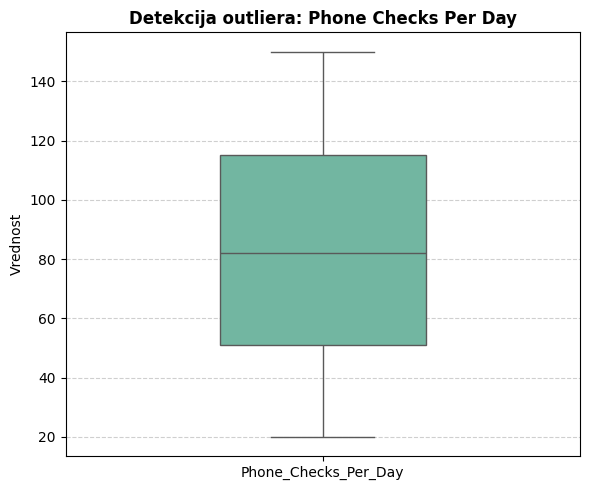

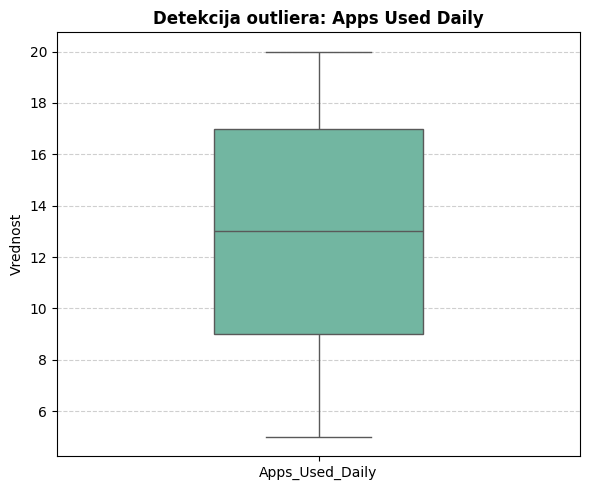

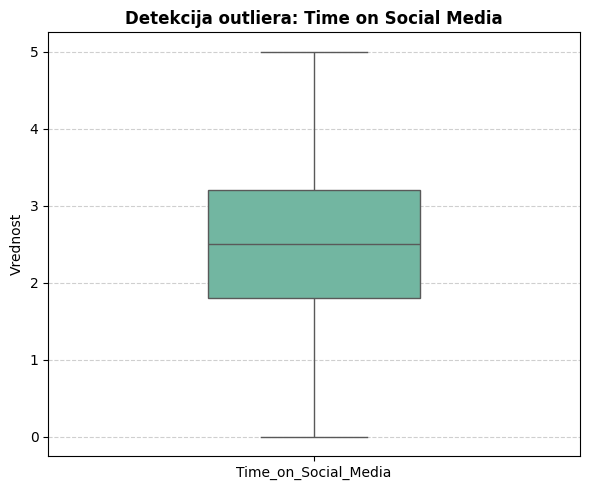

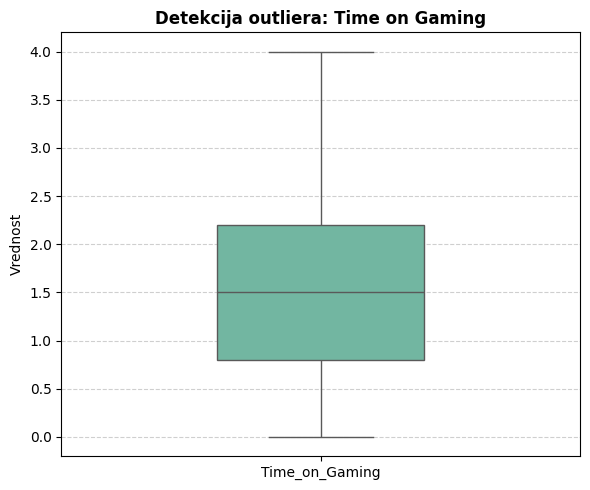

In [11]:
# Box plotovi
def plot_single_boxplot(df, column_name):

    if column_name not in df.columns:
        print(f"Greška: Kolona '{column_name}' ne postoji u DataFrame-u.")
        return

    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f"Greška: Kolona '{column_name}' nije numerička i ne može se nacrtati boxplot.")
        return

    plt.figure(figsize=(6, 5))

    sns.boxplot(y=df[column_name],
                x=[column_name]*len(df),
                palette='Set2',
                width=0.4,
                hue=[column_name]*len(df),
                legend=False)

    clean_title = column_name.replace('_', ' ')
    plt.title(f'Detekcija outliera: {clean_title}', fontsize=12, fontweight='bold')
    plt.ylabel('Vrednost')
    plt.xlabel('') # Brišemo x-label jer je naziv već u naslovu
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_single_boxplot(df, 'Daily_Usage_Hours')
plot_single_boxplot(df, 'Addiction_Level')
plot_single_boxplot(df, 'Weekend_Usage_Hours')
plot_single_boxplot(df, 'Sleep_Hours')
plot_single_boxplot(df, 'Phone_Checks_Per_Day')
plot_single_boxplot(df, 'Apps_Used_Daily')
plot_single_boxplot(df, 'Time_on_Social_Media')
plot_single_boxplot(df, 'Time_on_Gaming')

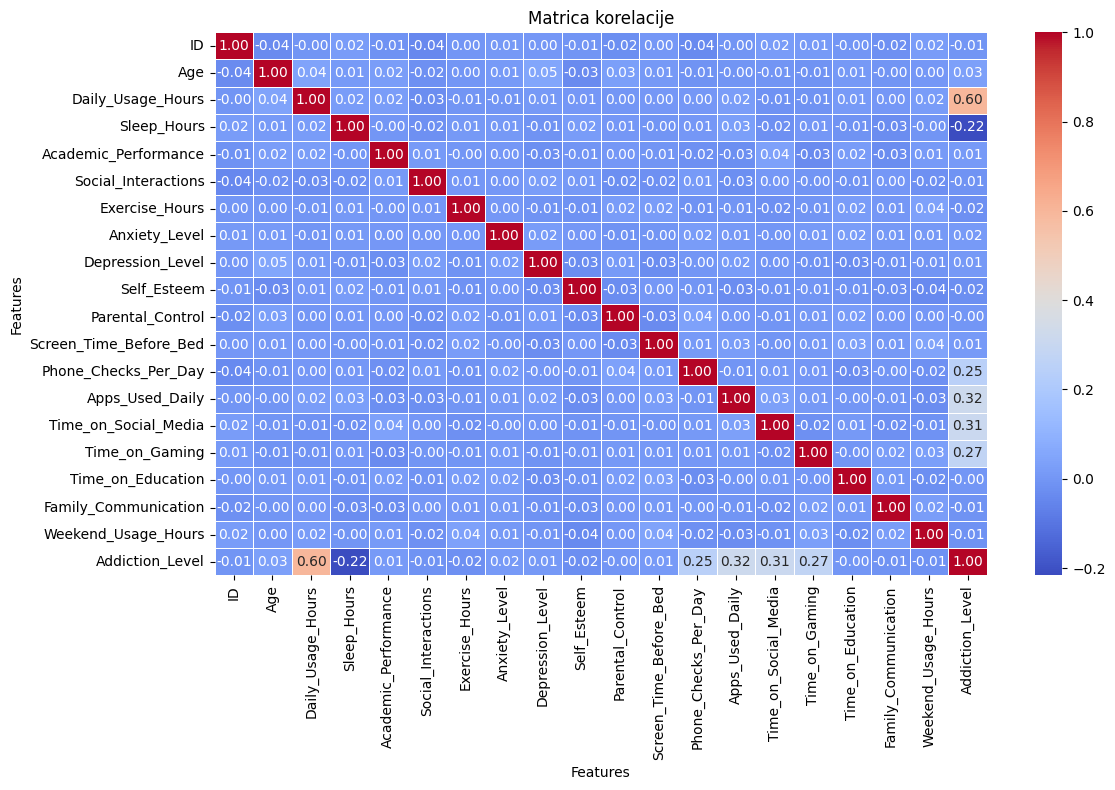

In [12]:
# Matrica korelacije
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrica korelacije")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

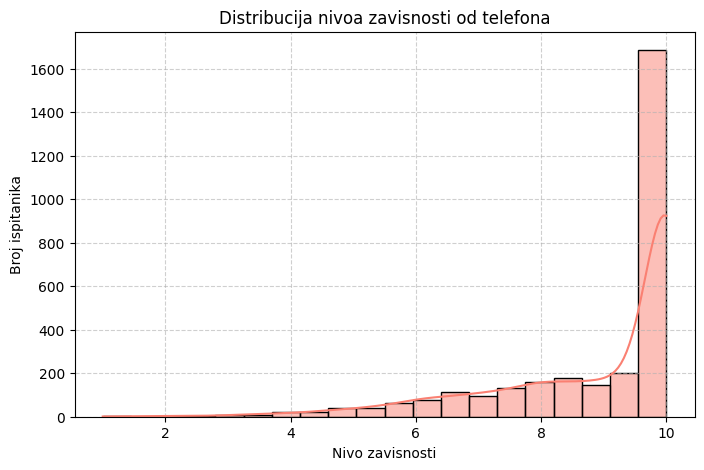

In [13]:
# Distribucija target varijable - Addiction Level
# Distribucija nivoa zavisnosti pokazuje da je većina ispitanika u datasetu na visokom nivou zavisnosti (9–10).
# Distribucija je asimetrična i naglašena prema većim vrednostima, što može uticati na performanse modela i dovesti do pristrasnosti u predviđanju.
plt.figure(figsize=(8,5))
sns.histplot(df['Addiction_Level'], bins=20, kde=True, color='salmon')

plt.title('Distribucija nivoa zavisnosti od telefona')
plt.xlabel('Nivo zavisnosti')
plt.ylabel('Broj ispitanika')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()